In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_pure_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 23/12 #NOTE: changed!
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

# Mojito light EMRI_G
# m1 = 6.72e5
# m2 = 9.84e1
# a = 0.5
# p0 = 15.7117
# e0 = 0.7440
# xI0 = 1.0
# dist = 4.755
# qS = 0.5906
# phiS = 3.5808
# qK = 1.1707
# phiK = 3.8495
# Phi_phi0 = 3.1940
# Phi_theta0 = 3.3780
# Phi_r0 = 0.6038

def icrs_to_ecliptic(qK_icrs, phiK_icrs, eps_deg=23.43929111):
    """
    Convert a sky direction (colatitude, longitude) from the ICRS/equatorial
    frame (qK = pi/2 - dec, phiK = ra) to the ecliptic frame (SSB frame used
    by the LISA response, is_ecliptic_latitude=False convention) via the
    standard equatorial<->ecliptic rotation with J2000 mean obliquity eps.
    """
    dec = np.pi / 2 - qK_icrs
    ra = phiK_icrs
    eps = np.deg2rad(eps_deg)

    sin_beta = np.sin(dec) * np.cos(eps) - np.cos(dec) * np.sin(ra) * np.sin(eps)
    beta = np.arcsin(sin_beta)

    y = np.cos(dec) * np.sin(ra) * np.cos(eps) + np.sin(dec) * np.sin(eps)
    x = np.cos(dec) * np.cos(ra)
    lam = np.arctan2(y, x) % (2 * np.pi)

    qK_ecl = np.pi / 2 - beta
    phiK_ecl = lam
    return qK_ecl, phiK_ecl

# Mojito light EMRI_C
m1 = 3.54e6
m2 = 8.01e1
a = 0.950
p0 = 7.3890
e0 = 0.3160
xI0 = 1.0000
dist = 4.858
qS = 2.0420
phiS = 5.7873
qK, phiK = icrs_to_ecliptic(1.6633, 1.7431)  # catalog qK/phiK are in ICRS, convert to ecliptic
Phi_phi0 = 2.4044
Phi_theta0 = 0.2850
Phi_r0 = 0.9743

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    """
    Coherent (pure) f-statistic (loglike_pure_noise.LogLike), row-by-row.

    Calls LogLike.__call__ once per row instead of the batched
    log_density_batch path.
    """
    params = np.asarray(params)
    B = params.shape[0]
    logl = np.empty(B, dtype=np.float64)
    for b in range(B):
        logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = params[b]
        qS_i = np.arccos(cosqS_i)
        theta = [
            10**logm1, 10**logm2, a_i, p0_i, e0_i,
            xI0, dist, qS_i, phiS_i, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0,
        ]
        try:
            logl[b] = loglike_obj(theta)
        except Exception:
            logl[b] = -np.inf
    return logl


def prior_transform(u):
    # from stage1_anneal
    # logm1lim = [5.82507, 5.82762]
    # logm2lim = [1.99252, 1.99310]
    # alim = [0.49334, 0.50078]
    # p0lim = [15.70599, 15.75367]
    # e0lim = [0.74388, 0.74418]
    # cosqSlim = [0.79926, 0.86149]    
    # phiSlim = [3.48384, 3.66905]

    # logm1lim = [5.82663, 5.82804]
    # logm2lim = [1.99282, 1.99316]
    # alim =  [0.49785, 0.50193]
    # p0lim = [15.69935, 15.72547]
    # e0lim = [0.74392, 0.74409]
    # cosqSlim = [0.80724, 0.85206]
    # phiSlim =  [3.49931, 3.62436]

    # emri c
    logm1lim = [6.54808, 6.54911]
    logm2lim = [1.90229, 1.90370]
    alim =  [0.94932, 0.95003]
    p0lim = [7.38774, 7.39225]
    e0lim = [0.31562, 0.31965]
    cosqSlim = [-1.0, 1.0]
    phiSlim =  [0.0, 2*np.pi]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [6.54808, 6.54911]
    logm2lim = [1.90229, 1.90370]
    alim =  [0.94932, 0.95003]
    p0lim = [7.38774, 7.39225]
    e0lim = [0.31562, 0.31965]
    cosqSlim = [-1.0, 1.0]
    phiSlim =  [0.0, 2*np.pi]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u


Using dt=10s, T=1.9166666666666667yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_c/stage2_f/'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [4]:
sampler.now_covariances

[array([[ 2.35774096e-01, -1.50178125e-02, -1.41770361e-02,
         -9.70565645e-03,  5.67266952e-05, -3.80915367e-03,
          1.95541368e-02],
        [-1.50178125e-02,  2.52649812e-01,  7.15125043e-03,
          9.62730956e-03,  1.03675368e-02,  1.94006746e-03,
         -1.22443169e-02],
        [-1.41770361e-02,  7.15125043e-03,  3.19869461e-01,
         -3.14545631e-03,  1.20508709e-02, -1.37802210e-02,
          5.46220543e-03],
        [-9.70565645e-03,  9.62730956e-03, -3.14545631e-03,
          2.85830097e-01,  2.16686157e-03,  1.85875670e-02,
          1.22479997e-02],
        [ 5.67266952e-05,  1.03675368e-02,  1.20508709e-02,
          2.16686157e-03,  2.78295922e-01,  2.43575836e-03,
         -3.19536243e-03],
        [-3.80915367e-03,  1.94006746e-03, -1.37802210e-02,
          1.85875670e-02,  2.43575836e-03,  2.66211551e-01,
         -1.47732752e-02],
        [ 1.95541368e-02, -1.22443169e-02,  5.46220543e-03,
          1.22479997e-02, -3.19536243e-03, -1.47732752e-02

In [5]:
len(sampler.now_covariances)

1

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.54859938, 1.90308   , 0.94983268, 7.39078333, 0.31567972,
        0.21439443, 3.07039144]])

In [9]:
param_true

[6.549003262025788,
 1.9036325160842376,
 0.95,
 7.389,
 0.316,
 -0.45395911390155774,
 5.7873]

In [7]:
log_density(maxld_pt1)

array([27.89125615])

In [8]:
log_density([param_true])

array([115.77939715])

In [10]:
param_ranges = [(6.54808,  6.54911),
                (1.90229,  1.90370),
                (0.94932,  0.95003),
                (7.38774,  7.39225),
                (0.31562,  0.31965),
                (-1,1),
                (0.0, 2 * np.pi)
                ]
param_ranges

[(6.54808, 6.54911),
 (1.90229, 1.9037),
 (0.94932, 0.95003),
 (7.38774, 7.39225),
 (0.31562, 0.31965),
 (-1, 1),
 (0.0, 6.283185307179586)]

In [11]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[6.549003262025788,
 1.9036325160842376,
 0.95,
 7.389,
 0.316,
 -0.45395911390155774,
 5.7873]

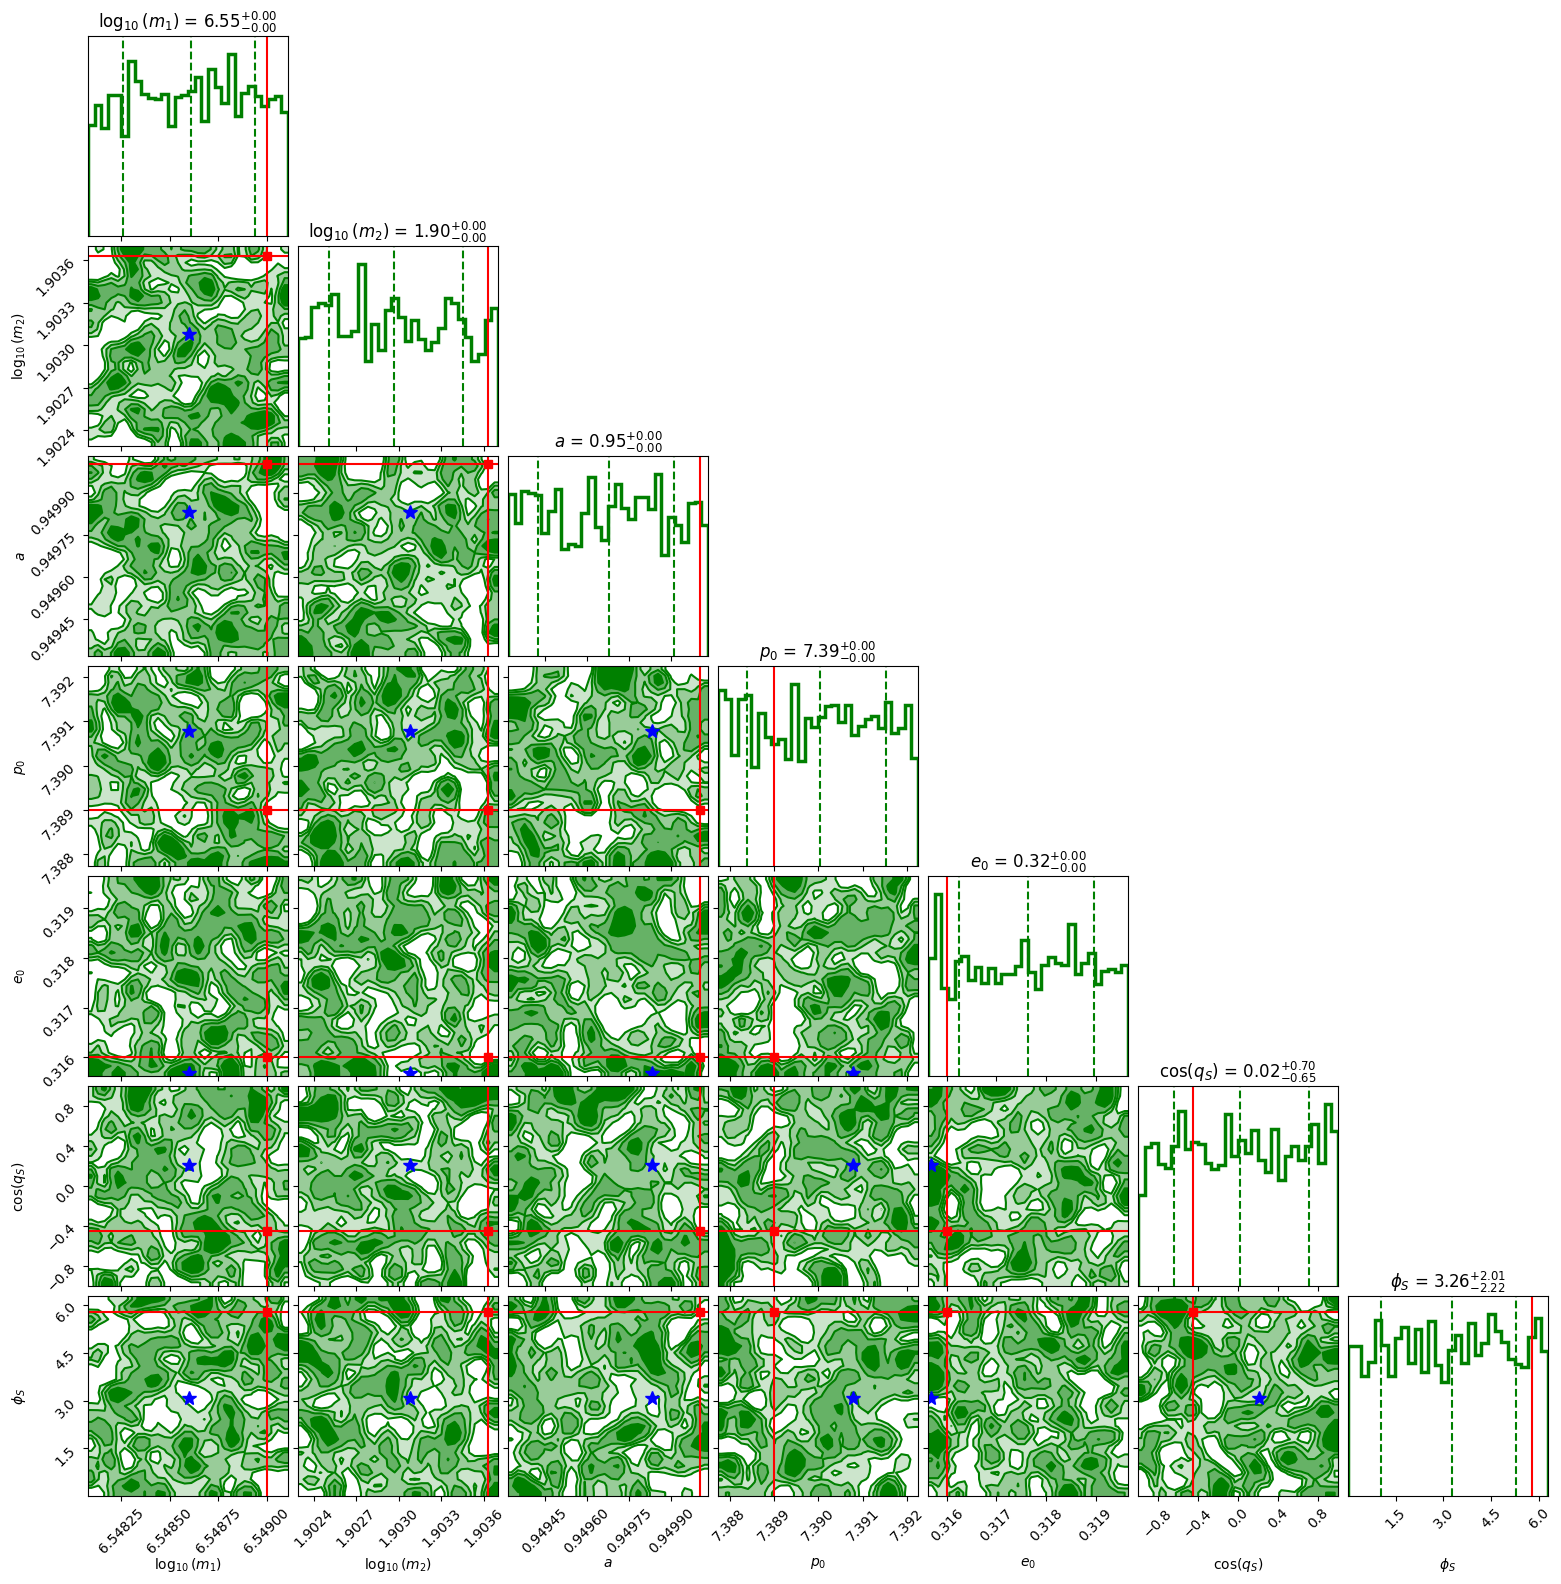

In [12]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)


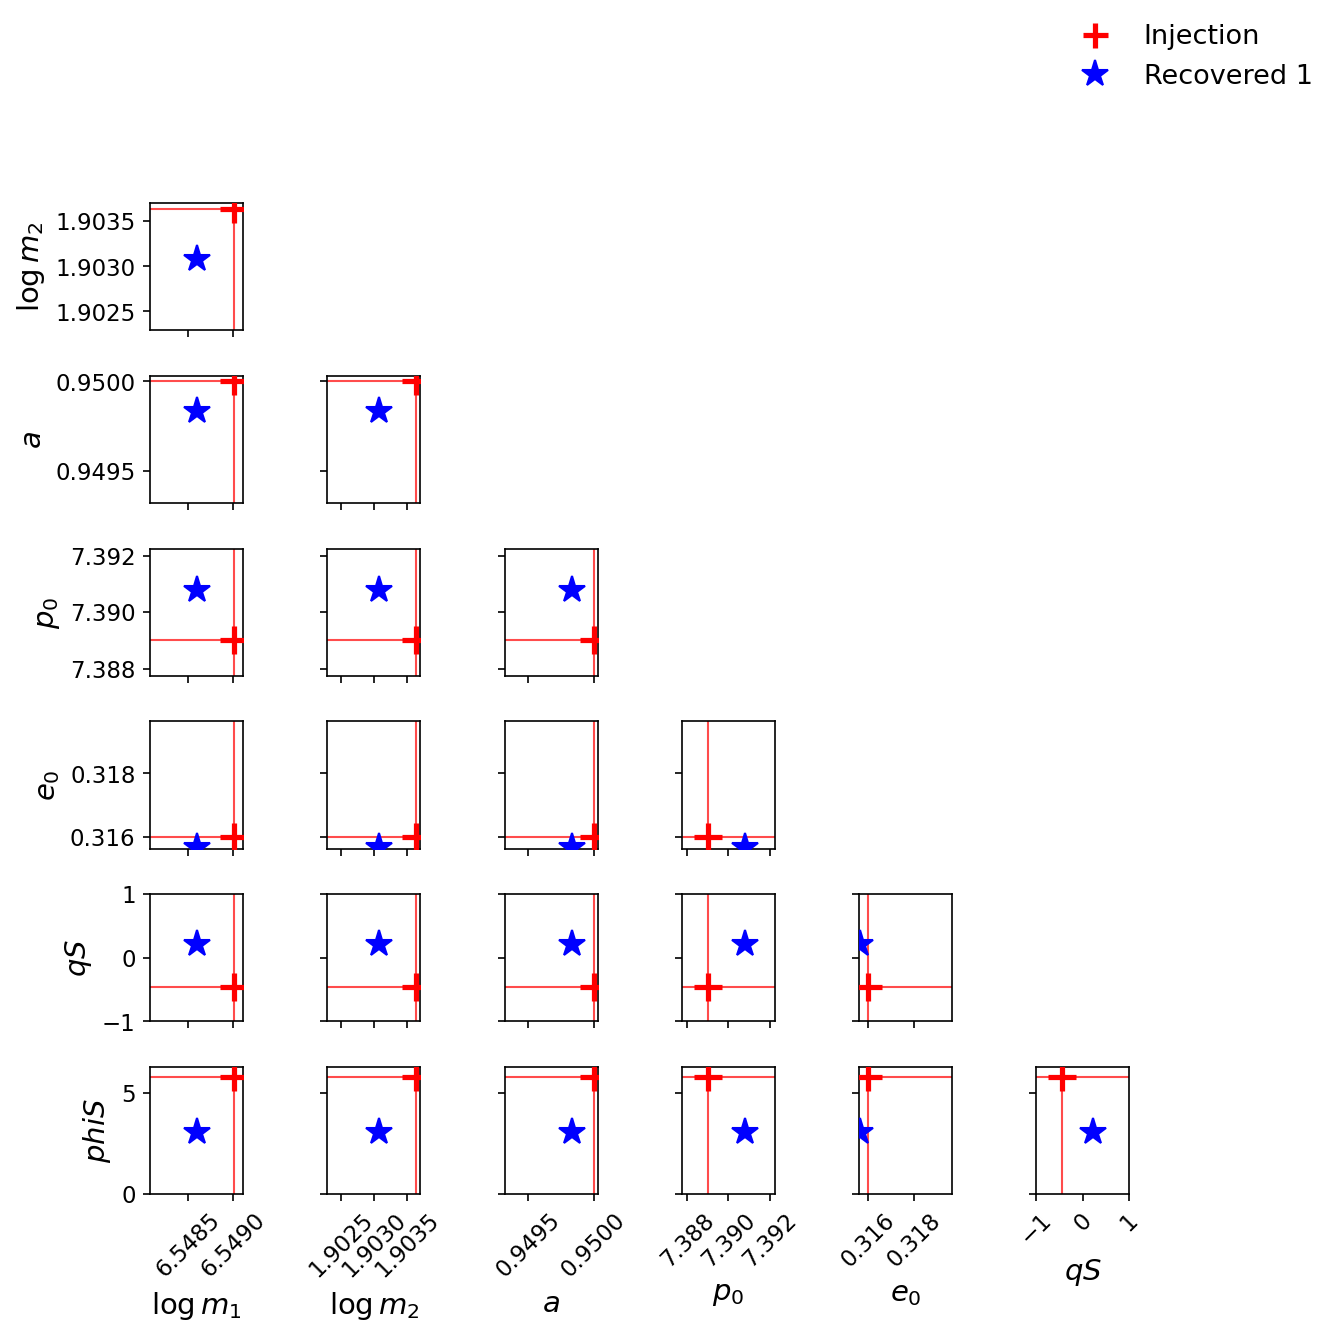

In [13]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()


# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
    # Line2D([0], [0], color='orange', marker='*', ls='', ms=13,          label='Recovered 2'),
    # Line2D([0], [0], color='pink', marker='*', ls='', ms=13,          label='Recovered 3'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [14]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[6.54859938, 1.90308   , 0.94983268, 7.39078333, 0.31567972,
        0.21439443, 3.07039144]])

In [15]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [16]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [17]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


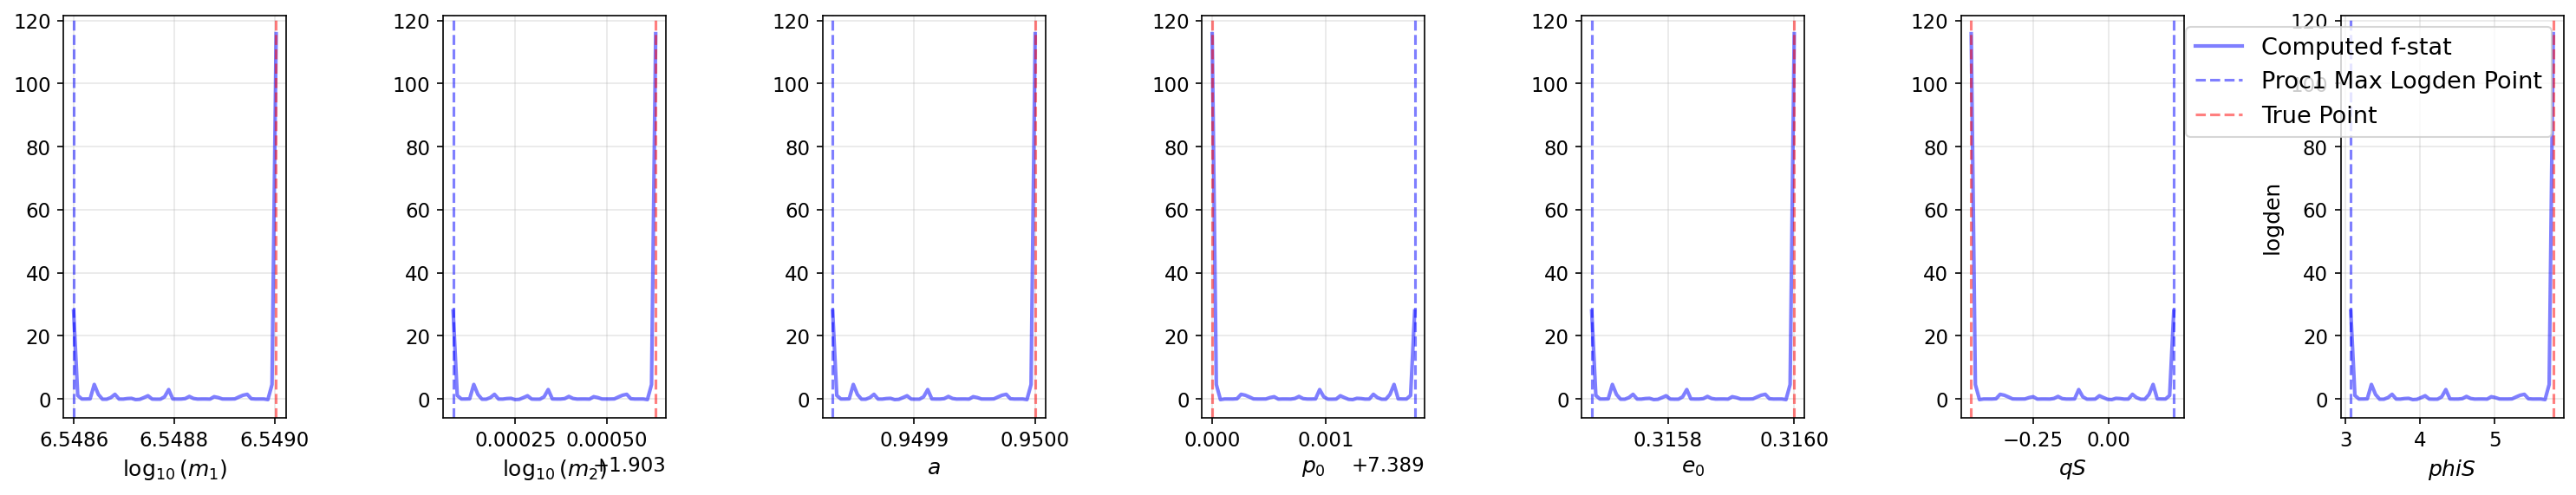

In [18]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [19]:
import numpy as np

def sky_antipode(qS, phiS):
    """
    Antipodal sky point: qS -> pi - qS, phiS -> phiS + pi (mod 2pi).
    qS: colatitude [rad], phiS: azimuth [rad].
    """
    qS_anti = np.pi - qS
    phiS_anti = (phiS + np.pi) % (2 * np.pi)
    return qS_anti, phiS_anti

# EMRI_C true values
qS_true, phiS_true = 2.0420, 5.7873
qS_anti, phiS_anti = sky_antipode(qS_true, phiS_true)

print(f"qS_true={qS_true:.4f}  phiS_true={phiS_true:.4f}  cos(qS_true)={np.cos(qS_true):.5f}")
print(f"qS_anti={qS_anti:.4f}  phiS_anti={phiS_anti:.4f}  cos(qS_anti)={np.cos(qS_anti):.5f}")


qS_true=2.0420  phiS_true=5.7873  cos(qS_true)=-0.45396
qS_anti=1.0996  phiS_anti=2.6457  cos(qS_anti)=0.45396


In [20]:
maxld_pt1

array([6.54859938, 1.90308   , 0.94983268, 7.39078333, 0.31567972,
       0.21439443, 3.07039144])